⏳ 正在加载原始数据，重建运动分析上下文...
🎯 锁定剧烈运动片段！跨度: 30 秒


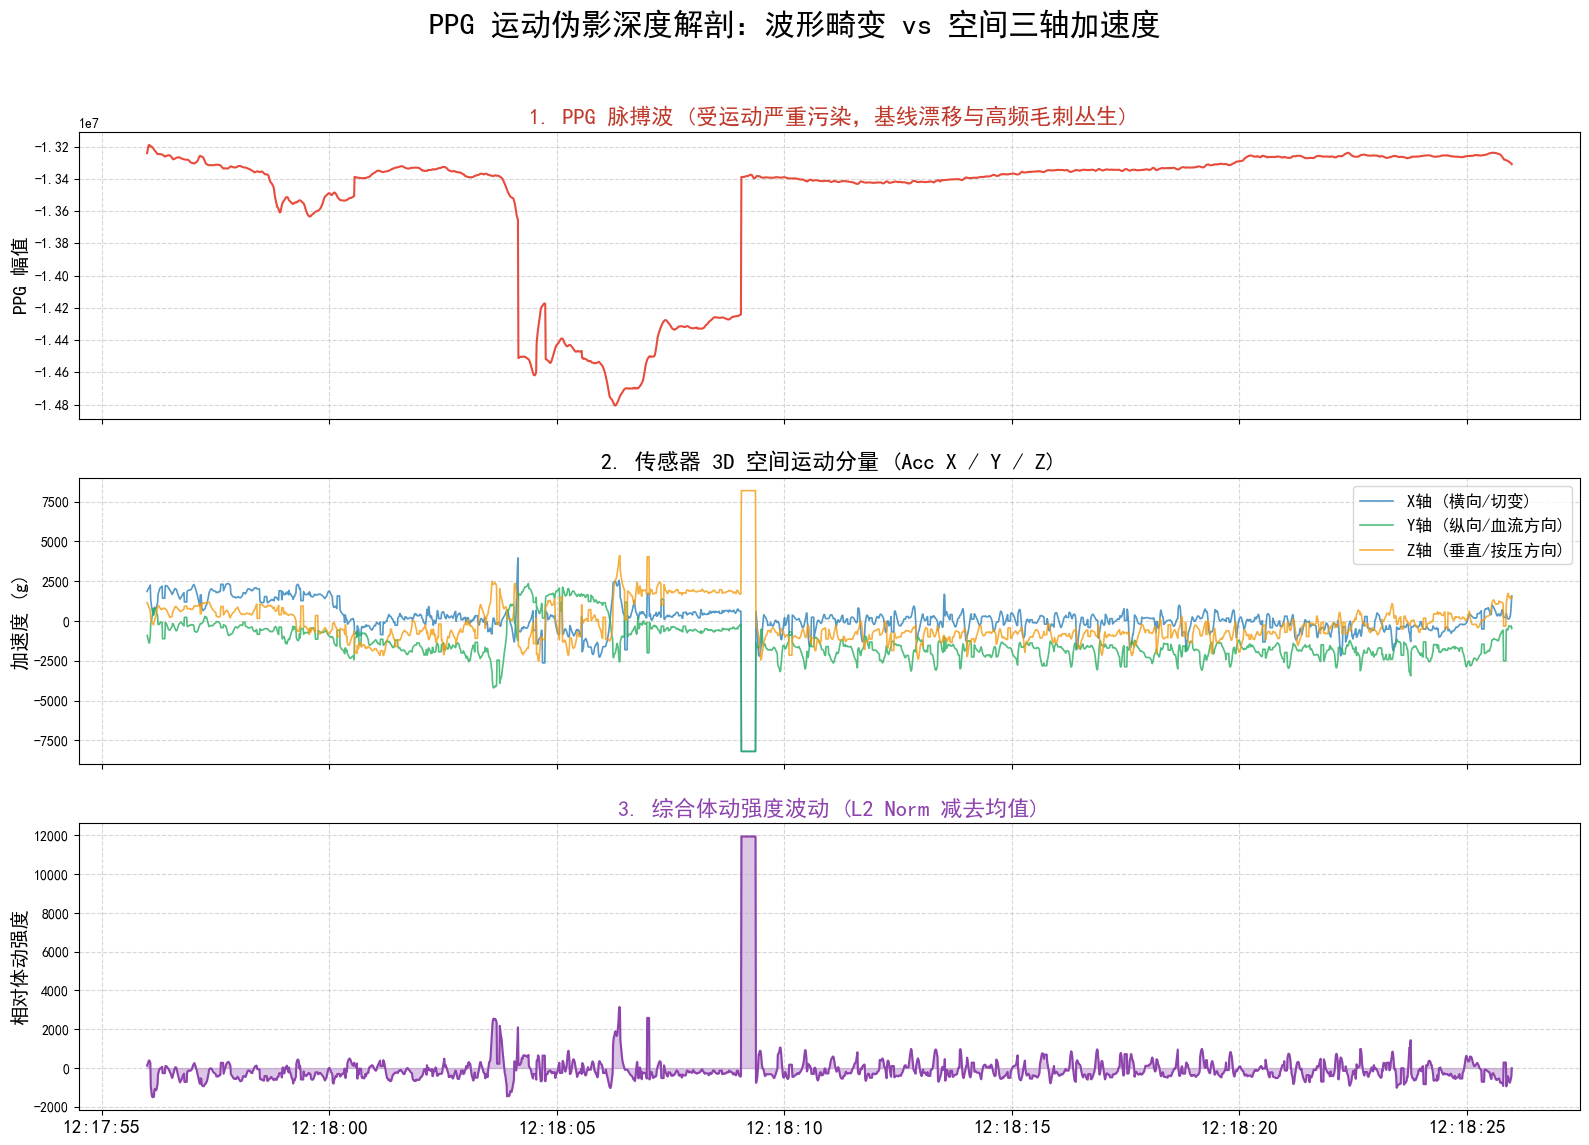

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========== 1. 设置字体与环境 ==========
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False   
import warnings
warnings.filterwarnings('ignore')

print("⏳ 正在加载原始数据，重建运动分析上下文...")

# ========== 2. 读取与预处理原始数据 ==========
# 重新读取最原始的滤波数据，绕开 step11 的切割逻辑
df = pd.read_csv("../data/raw/may_filtered.csv")

# 重建时间轴
datetimestr = df.date + ' ' + df.time
df['datetime'] = pd.to_datetime(datetimestr, format="%d-%m-%Y %H:%M:%S").astype('datetime64[s]')
df.drop(['date', 'time'], inplace=True, axis=1)

# 翻转 PPG 信号 (修正光吸收量反相)
df['ied'] = -1. * df['ied']

# 计算 L2 范数综合运动强度 (为了找运动最剧烈的地方)
# 注意：有些设备为了去重力，会减去 1g，这里我们看相对变化即可
df['motion_l2'] = np.linalg.norm(df[['accX', 'accY', 'accZ']].values, axis=1)

# ========== 3. 自动定位“运动重灾区” ==========
ASSUMED_FS = 100
DISPLAY_SEC = 30  # 展示 30 秒的连续运动过程
window_points = ASSUMED_FS * DISPLAY_SEC

# 用 5 秒的滑动窗口计算平均运动强度，找到全局运动最剧烈的中心点
rolling_motion = df['motion_l2'].rolling(window=ASSUMED_FS * 5).var() 
max_motion_idx = rolling_motion.idxmax()

# 截取该中心点前后的数据
start_idx = max(0, max_motion_idx - window_points // 2)
end_idx = min(len(df), max_motion_idx + window_points // 2)
df_sub = df.iloc[start_idx:end_idx].copy()

# 重建亚秒级（毫秒）时间轴，让波形平滑展开
start_time = df_sub['datetime'].iloc[0]
sub_sec_time = start_time + pd.to_timedelta(np.arange(len(df_sub)) / ASSUMED_FS, unit='s')

# ========== 4. 绘制高级三联对照图 ==========
print(f"🎯 锁定剧烈运动片段！跨度: {DISPLAY_SEC} 秒")

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("PPG 运动伪影深度解剖：波形畸变 vs 空间三轴加速度", fontsize=22, fontweight='bold')

# ---------------- 图 1：PPG 原始波形 ----------------
axes[0].plot(sub_sec_time, df_sub['ied'], color='#e74c3c', linewidth=1.5)
axes[0].set_title("1. PPG 脉搏波 (受运动严重污染，基线漂移与高频毛刺丛生)", fontsize=16, fontweight='bold', color='#c0392b')
axes[0].set_ylabel("PPG 幅值", fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# ---------------- 图 2：三轴加速度分量 (X / Y / Z) ----------------
axes[1].plot(sub_sec_time, df_sub['accX'], label='X轴 (横向/切变)', color='#2980b9', alpha=0.8, linewidth=1.2)
axes[1].plot(sub_sec_time, df_sub['accY'], label='Y轴 (纵向/血流方向)', color='#27ae60', alpha=0.8, linewidth=1.2)
axes[1].plot(sub_sec_time, df_sub['accZ'], label='Z轴 (垂直/按压方向)', color='#f39c12', alpha=0.8, linewidth=1.2)
axes[1].set_title("2. 传感器 3D 空间运动分量 (Acc X / Y / Z)", fontsize=16, fontweight='bold')
axes[1].set_ylabel("加速度 (g)", fontsize=14)
axes[1].legend(loc='upper right', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# ---------------- 图 3：综合运动强度 (L2 Norm) ----------------
# 减去均值（近似去除重力分量）方便观察相对波动
motion_centered = df_sub['motion_l2'] - df_sub['motion_l2'].mean()
axes[2].fill_between(sub_sec_time, 0, motion_centered, color='#8e44ad', alpha=0.3)
axes[2].plot(sub_sec_time, motion_centered, color='#8e44ad', linewidth=1.5)
axes[2].set_title("3. 综合体动强度波动 (L2 Norm 减去均值)", fontsize=16, fontweight='bold', color='#8e44ad')
axes[2].set_ylabel("相对体动强度", fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# X轴时间格式化 (因为 sharex=True，只需设置最底下的轴)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
axes[2].tick_params(axis='x', labelsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0)
plt.show()